### Imports

In [6]:
import json
import random
import warnings
from pathlib import Path

import numpy as np
import torch
import torchaudio
from matplotlib import pyplot as plt
from snntorch import spikegen
from torch import nn
from tqdm import tqdm

from src.config import CONFIG
from src.preprocessing import get_snn_pipeline

warnings.filterwarnings("ignore", category=UserWarning)

### Constants

In [7]:
INPUT_DIR = Path('../../data/BatvisionV2')
OUTPUT_DIR = Path('../../processed/BatvisionV2')

### Encoding Functions

In [8]:
def compute_p10_depth(audio_path: Path) -> float:
    env_dir = audio_path.parent.parent
    index = audio_path.stem.split('_')[1]
    depth_path = env_dir / 'depth' / f'depth_{index}.npy'
    depth_map = np.load(depth_path)
    valid = depth_map[depth_map > 0]

    return np.percentile(valid, 10)

def process_file(labels: dict, audio_path: Path, pipeline: nn.Module, output_dir: Path) -> None:
    """Process each raw .wav file, converting to a spike tensor and saving the p10 depth as a label."""
    try:
        waveform, _ = torchaudio.load(audio_path)
        processed = pipeline(waveform)

        # Permute to (Time, Channels, n_mels) as spikegen requires time to be first
        transposed = processed.permute(2, 0, 1)

        spikes = spikegen.delta(transposed, threshold=CONFIG.batvision.delta_threshold, off_spike=True)

        location_dir = output_dir / audio_path.parent.parent.name
        location_dir.mkdir(parents=True, exist_ok=True)
        save_path = location_dir / f'{audio_path.stem}.pt'
        torch.save(spikes.to(torch.float32), save_path)

        # Compute and store p10 depth label
        p10 = compute_p10_depth(audio_path)
        key = f'{audio_path.parent.parent.name}/{audio_path.stem}'
        labels[key] = p10

    except Exception as e:
        print(f'Error processing {audio_path}: {e}')

def visualise_spikes(spike_tensor: torch.Tensor, file_name: str, p10: float) -> None:
      fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

      for ch, (ax, ch_name) in enumerate(zip(axes, ['Left', 'Right'])):
          spikes = spike_tensor[:, ch, :].detach().cpu().numpy()
          time_steps, n_bins = spikes.shape

          on_times, on_bins = (spikes == 1).nonzero()
          off_times, off_bins = (spikes == -1).nonzero()

          ax.scatter(on_times, on_bins, color='green', marker='|', s=50, label='On (+)')
          ax.scatter(off_times, off_bins, color='red', marker='|', s=50, label='Off (-)')
          ax.set_title(f'{ch_name} Channel')
          ax.set_xlabel('Time Steps')
          ax.set_ylabel('Gammatone Bin')
          ax.set_ylim(-0.5, n_bins - 0.5)
          ax.set_xlim(-0.5, time_steps - 0.5)
          ax.legend(loc='upper right')
          ax.grid(True, alpha=0.3)

      fig.suptitle(f'Spike Raster plot for {file_name} | p10 depth: {p10:.0f} mm')
      plt.tight_layout()
      plt.show()

### Main

Found 3120 wav files, processing...


Processing: 100%|██████████| 3120/3120 [00:17<00:00, 177.31files/s]


Preprocessing for SNN done.
Labels stored at ../../processed/BatvisionV2/labels.json


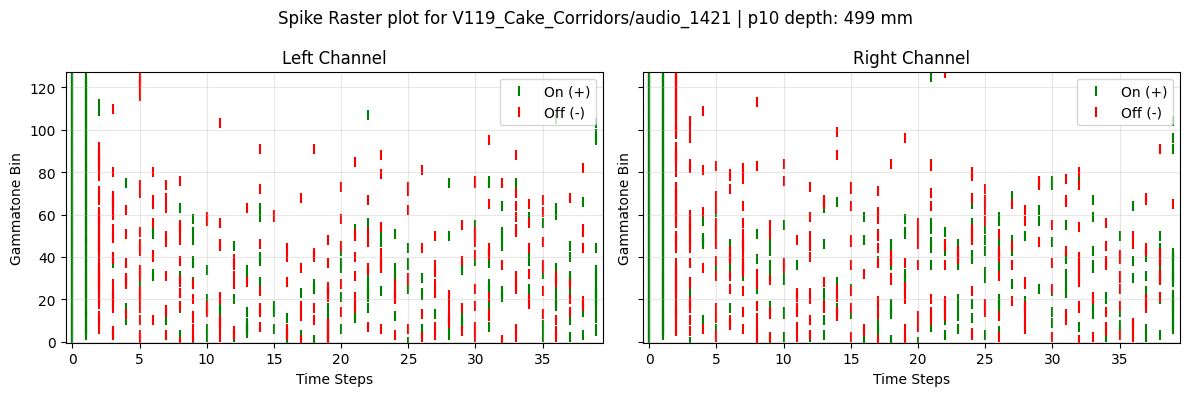

In [9]:
if __name__ == '__main__':
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    wav_files = list(INPUT_DIR.rglob('*.wav'))
    print(f'Found {len(wav_files)} wav files, processing...')

    labels = {}
    pipeline = get_snn_pipeline(CONFIG.batvision)
    for f in tqdm(wav_files, desc='Processing', unit='files'):
        process_file(labels, f, pipeline, OUTPUT_DIR)

    with open(OUTPUT_DIR / 'labels.json', 'w') as f:
        json.dump(labels, f, indent=2)

    print('Preprocessing for SNN done.')
    print(f'Labels stored at {OUTPUT_DIR / "labels.json"}')

    # Plot a random sample to verify encoding works
    processed_files = list(OUTPUT_DIR.rglob('*.pt'))
    random_file = random.choice(processed_files)
    spikes = torch.load(random_file)
    key = f'{random_file.parent.name}/{random_file.stem}'
    visualise_spikes(spikes, key, labels.get(key))